<a href="https://colab.research.google.com/github/NMelbard/PBL1/blob/main/PBL2/pbl2_heparin_exocytosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dH/dt = (heparosan to heparin conversion equation) - vpackaging,hill([H]) - kdegradation*[H]

dR/dt = (1/q)vpackaging,hill([H]) - krelease*[R]

dC/dt = (some time dependent pulse function) - kca*[C]

dV/dt = krelease*[R] - kexo,hill(C)*V

dS/dt = q*kexo,hill(C)*V

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [7]:
def v_packaging(H, K, Vmax, n):
  return Vmax * H**n / (K**n + H**n)

def ca_pulse(t, A=1.0, t0=1.0, sigma=0.1): #gaussian pulse function
    return A * np.exp(-((t - t0)**2) / (2 * sigma**2))

def k_exo(C, K, kmax, n):
  return kmax * C**n / (K**n + C**n)

In [8]:
def f_hep(t, y, c, k_sulfation):
  '''
  c = [Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q]
  '''
  # Unpack state variables: [Heparosan, Heparin, PAPS, Reserve Vesicles, Calcium, Release Vesicles, Secreted Heparin]
  Hs, Hp, PAPS, R, C, V, S = y

  # Heparosan to Heparin conversion rate
  v_sulfation = k_sulfation * Hs * PAPS

  # Unpack parameters from c for clarity and correct indexing
  Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q = c

  # ODEs for the combined system
  dHs_dt = -v_sulfation
  dHp_dt = v_sulfation - v_packaging(Hp, Kpack, Vmax, n1) - kdeg * Hp
  dPAPS_dt = -v_sulfation

  dR_dt = (1/q) * v_packaging(Hp, Kpack, Vmax, n1) - krel * R # Corrected c[8] to q
  dC_dt = ca_pulse(t) - kca * C
  dV_dt = krel * R - k_exo(C, Kexo, kmax, n2) * V # Corrected: multiplied by V
  dS_dt = q * k_exo(C, Kexo, kmax, n2) * V # Corrected: q * (rate) * V

  return [dHs_dt, dHp_dt, dPAPS_dt, dR_dt, dC_dt, dV_dt, dS_dt]

In [9]:
#parameters that i kind of just made up
Kpack = 0.1 #affinity constant for packaging heparin (mM)
Kexo = 0.001 #affinity constant for exocytosis process (mM)
Vmax = 0.1 #maximum packaging rate coefficient (mM/min)
kmax = 5.0 #maximum exocytosis rate coefficient (1/min)
n1 = 1 #hill coefficent for heparin packaging
n2 = 2 #hill coefficient for exocytosis
kdeg = 0.05 #heparin degradation coefficient (1/min)
krel = 0.3 #rate of reserve converting to release vesicles coefficient (1/min)
kca = 5.0 #calcium uptake coefficient (1/min)
q = 1e-3 #amount heparin molecules per vesicle (mM)
k_sulfation = 0.05 # lumped reaction rate constant for sulfation (1/(mM*min))

In [10]:
c = [Kpack, Kexo, Vmax, kmax, n1, n2, kdeg, krel, kca, q]

# Initial conditions for [Hs, Hp, PAPS, R, C, V, S]
# Using initial conditions from the sulfation model (Hs0, Hp0, PAPS0) and existing exocytosis model
Hs0 = 10.0    # initial heparosan (from sulfation model)
Hp0 = 0.0     # initial heparin (from sulfation model, and H in exocytosis)
PAPS0 = 12.0  # initial PAPS (from sulfation model)
R0 = 90.0     # initial R (from existing exocytosis model in y_init)
C0 = 0.0      # initial C (from existing exocytosis model in y_init)
V0 = 10.0     # initial V (from existing exocytosis model in y_init)
S0 = 0.0      # initial S (from existing exocytosis model in y_init)

y_init = [Hs0, Hp0, PAPS0, R0, C0, V0, S0]

tspan = np.linspace(0, 720, 1000)
sol = solve_ivp(lambda t, y: f_hep(t, y, c, k_sulfation), [tspan[0], tspan[-1]], y_init, t_eval=tspan)
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  7.207e-01 ...  7.193e+02  7.200e+02]
        y: [[ 1.000e+01  6.904e+00 ...  9.637e-32  8.967e-32]
            [ 0.000e+00  2.971e+00 ...  1.014e-32  9.439e-33]
            ...
            [ 1.000e+01  7.316e+00 ... -8.340e-07  2.240e-07]
            [ 0.000e+00  2.643e-02 ...  3.973e+00  3.973e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 7586
     njev: 0
      nlu: 0


In [11]:
eqs = ["Heparosan", "Heparin", "PAPS", "Reserve Vesicles", "Calcium", "Ready Vesicles", "Exported Heparin"]

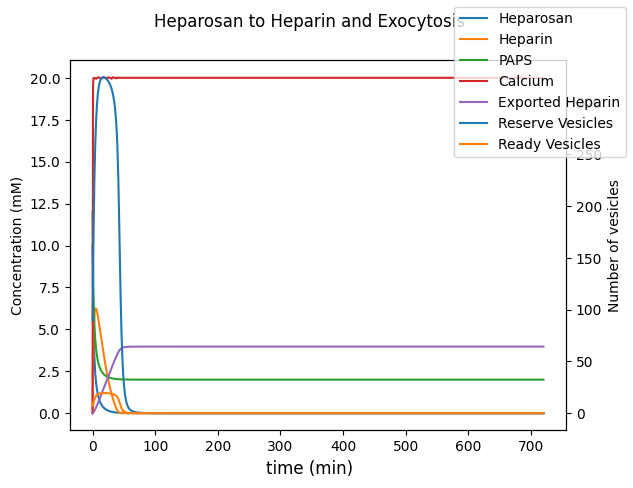

<Figure size 2400x1200 with 0 Axes>

In [15]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

plt.figure(figsize=(8,4),dpi=300)
for i, s in enumerate(sol.y):
  if eqs[i] in ["Reserve Vesicles", "Ready Vesicles"]:
    ax2.plot(sol.t, s, label=eqs[i])
  else:
    ax1.plot(sol.t, s, label=eqs[i])

fig.supxlabel('time (min)')
ax1.set_ylabel('Concentration (mM)')
ax2.set_ylabel('Number of vesicles')
fig.legend()
fig.suptitle('Heparosan to Heparin and Exocytosis')
plt.show()